# Retail Performance Analytics

# Business Analysis

This notebook builds on the work completed in the previous stages of the project.

After understanding the dataset and preparing it for analysis, the focus shifts to answering business questions using the cleaned data.

Each section explores one business question, presents the results and explains what they mean for the business.

## Project Roadmap

| Stage | Status |
|--------|--------|
| Business Understanding | ✅ Completed |
| Data Understanding | ✅ Completed |
| Data Cleaning | ✅ Completed |
| Business Analysis | 🟡 In Progress |
| SQL Analysis | ⏳ Planned |
| Power BI Dashboard | ⏳ Planned |
| Executive Report | ⏳ Planned |

## Notebook Objectives

This notebook aims to:

- Assess overall business performance.
- Identify the most valuable customers.
- Evaluate product performance.
- Compare sales across countries.
- Analyse sales trends over time.

## Analytical Approach

Each section answers a business question using the cleaned dataset.

The results are then interpreted through observations and business insights.

## Business Questions

This analysis seeks to answer the following business questions:

1. How is the business performing overall?
2. Who are the most valuable customers?
3. Which products drive revenue?
4. How does sales performance vary across countries?
5. How do sales evolve over time?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Pandas display options
pd.set_option("display.max_columns", None)

# Matplotlib default style
plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

#### Load Clean Dataset

In [14]:
clean_df = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    dtype={
        "InvoiceNo": str,
        "StockCode": str
    },
    parse_dates=["InvoiceDate"]
)

#### Observation

The cleaned dataset generated in the previous notebook is loaded from the **processed** folder.

InvoiceNo and StockCode are imported as text because they are business identifiers, while InvoiceDate is imported as a datetime column.

#### Dataset Overview

In [13]:
rows, columns = clean_df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 525,460
Columns: 8


#### Observation

The cleaned dataset contains only valid retail sales transactions after applying the cleaning rules defined in the previous notebook.

It is now ready for the business analyses presented throughout this project.

## Feature Engineering

The following variables are created to support the analyses presented in this notebook.

#### Line Total

The original dataset stores the quantity sold and the unit price separately.

The new variable combines both values and represents the total amount for each transaction line.

In [23]:
clean_df["LineTotal"] = (
    clean_df["Quantity"] *
    clean_df["UnitPrice"]
)

#### Validation

In [24]:
clean_df["LineTotal"].describe()

count    525460.000000
mean         20.252942
std         271.543898
min           0.000000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: LineTotal, dtype: float64

#### Observation

LineTotal represents the value of each transaction line and will be used in the analyses throughout this notebook.

### Year

The **Year** variable separates transactions by calendar year.

Although this dataset covers only two years, this variable makes it easier to organise the results by year.

In [17]:
clean_df["Year"] = (
    clean_df["InvoiceDate"]
    .dt.year
)

### Month

The **Month** variable stores the month as a number, making it easier to keep charts and tables in chronological order.

In [18]:
clean_df["Month"] = (
    clean_df["InvoiceDate"]
    .dt.month
)

### Month Name

The **MonthName** variable displays the month names, making tables and charts easier to read.

In [19]:
clean_df["MonthName"] = (
    clean_df["InvoiceDate"]
    .dt.month_name()
)

### Day of Week

The **DayOfWeek** variable is used to compare sales across the days of the week.

In [20]:
clean_df["DayOfWeek"] = (
    clean_df["InvoiceDate"]
    .dt.day_name()
)

### Hour

The **Hour** variable helps identify the busiest shopping hours.

In [21]:
clean_df["Hour"] = (
    clean_df["InvoiceDate"]
    .dt.hour
)

#### Validation

In [25]:
clean_df[
    [
        "InvoiceDate",
        "LineTotal",
        "Year",
        "Month",
        "MonthName",
        "DayOfWeek",
        "Hour"
    ]
].head()

,InvoiceDate,LineTotal,Year,Month,MonthName,DayOfWeek,Hour
0,2010-12-01 08:26:00,15.30,2010,12,December,Wednesday,8
1,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8
2,2010-12-01 08:26:00,22.00,2010,12,December,Wednesday,8
3,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8
4,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8


#### Observation

The new variables are now available for the remaining analyses in this notebook.

# Business Question 1

## How is the business performing overall?

This section provides an overview of the business before exploring customers, products, countries and sales trends in more detail.

### Business KPIs

#### Total Sales

In [27]:
total_sales = clean_df["LineTotal"].sum()

print(f"Total Sales: £{total_sales:,.2f}")

Total Sales: £10,642,110.80


#### Observation

Total Sales represents the total value of all completed sales included in the analytical dataset.

---

#### Total Orders

In [26]:
total_orders = clean_df["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 20,134


#### Observation

Each invoice represents one completed order.

Counting unique invoice numbers provides the total number of orders analysed.

---

#### Average Order Value

Average Order Value is calculated by dividing total sales by the number of completed orders.

In [36]:
invoice_total = (
    clean_df
    .groupby("InvoiceNo")["LineTotal"]
    .sum()
)

average_order_value = invoice_total.mean()

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £528.56


#### Observation

On average, customers spent **£528.56** per completed order.

#### Total Customers

In [28]:
total_customers = clean_df["CustomerID"].nunique()

print(f"Identified Customers: {total_customers:,}")

Identified Customers: 4,339


#### Observation

This metric includes only customers with a valid customer identifier.

Anonymous purchases remain part of the sales analysis but are not included in customer-level metrics.

---

#### Unique Products

In [37]:
unique_Products = clean_df["StockCode"].nunique()

print(f"unique Products: {unique_Products:,}")

unique Products: 3,925


#### Observation

This metric shows how many different products were sold during the analysed period.

---

#### Countries

In [30]:
total_countries = clean_df["Country"].nunique()

print(f"Countries: {total_countries}")

Countries: 38


#### Observation

Sales were recorded across multiple countries.

Country-level performance will be explored later in the notebook.

### Business Insight

These KPIs provide an overall picture of the business.

The following sections examine customers, products, countries and sales trends to understand the results in more detail.

---

# Business Question 2

## Who are the most valuable customers?

This section identifies the customers who contribute most to total sales.

The analysis focuses on customer spending and purchase frequency to understand how revenue is distributed across the customer base.

### Customer Revenue

In [62]:
customer_summary = (
    clean_df
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        TotalSales=("LineTotal", "sum"),
        Orders=("InvoiceNo", "nunique"),
        ItemsPurchased=("Quantity", "sum")
    )
)

customer_summary["AverageOrderValue"] = (
    customer_summary["TotalSales"] /
    customer_summary["Orders"]
).round(2)

customer_summary = customer_summary.sort_values(
    by="TotalSales",
    ascending=False
)

customer_summary.head(10)

,TotalSales,Orders,ItemsPurchased,AverageOrderValue
CustomerID,,,,
14646.0,280206.02,74,197491,3786.57
18102.0,259657.30,60,64124,4327.62
17450.0,194390.79,46,69973,4225.89
16446.0,168472.50,2,80997,84236.25
14911.0,143711.17,201,80490,714.98
12415.0,124914.53,21,77670,5948.31
14156.0,117210.08,55,57768,2131.09
17511.0,91062.38,31,64549,2937.50
16029.0,80850.84,63,40108,1283.35


#### Observation

The customers with the highest sales are not necessarily those with the highest number of orders.

The table shows different purchasing patterns, with some customers generating high revenue through fewer but larger purchases.

### Business Insight

Customer value cannot be measured by purchase frequency alone.

Analysing sales together with the number of orders and the average order value provides a more complete view of customer purchasing behaviour.

---

# Business Question 3

## Which products drive revenue?

This section examines product performance to identify which products contribute most to total sales.

Understanding product performance helps identify the products that have the greatest impact on the business.

### Product Revenue

In [66]:
product_summary = (
    clean_df
    .groupby(
        ["StockCode", "Description"]
    )
    .agg(
        TotalSales=("LineTotal", "sum"),
        QuantitySold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values(
        by="TotalSales",
        ascending=False
    )
)

product_summary.head(10)

,,TotalSales,QuantitySold,Orders
StockCode,Description,,,
DOT,DOTCOM POSTAGE,206248.77,708,708
22423,REGENCY CAKESTAND 3 TIER,174156.54,13862,1989
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37584,2193
47566,PARTY BUNTING,99445.23,18287,1686
85099B,JUMBO BAG RED RETROSPOT,94159.81,48375,2092
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
POST,POSTAGE,78101.88,3150,1126
M,Manual,77750.27,6990,294


#### Investigation

The initial ranking includes entries such as **DOTCOM POSTAGE**, **POSTAGE** and **Manual**.

Although these records contribute to total revenue, they represent operational charges rather than physical products.

Since the objective of this section is to identify the products that drive sales, these operational records will be excluded from the product ranking while remaining part of the overall dataset.

In [67]:
product_sales = product_summary[
    ~product_summary.index.get_level_values("StockCode")
    .isin(["DOT", "POST", "M"])
]

product_sales.head(10)

,,TotalSales,QuantitySold,Orders
StockCode,Description,,,
22423,REGENCY CAKESTAND 3 TIER,174156.54,13862,1989
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37584,2193
47566,PARTY BUNTING,99445.23,18287,1686
85099B,JUMBO BAG RED RETROSPOT,94159.81,48375,2092
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
23084,RABBIT NIGHT LIGHT,66870.03,30739,994
22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455


#### Validation

#### Observation

The ranking identifies the products that generated the highest sales during the analysed period.

The table also shows that product performance varies considerably, with some products generating high revenue through frequent purchases and others through larger order volumes.

### Business Insight

Looking at sales together with order frequency provides a better understanding of product performance.

Products that consistently appear across many orders may play a different role in the business from products that generate high revenue through a small number of large purchases.

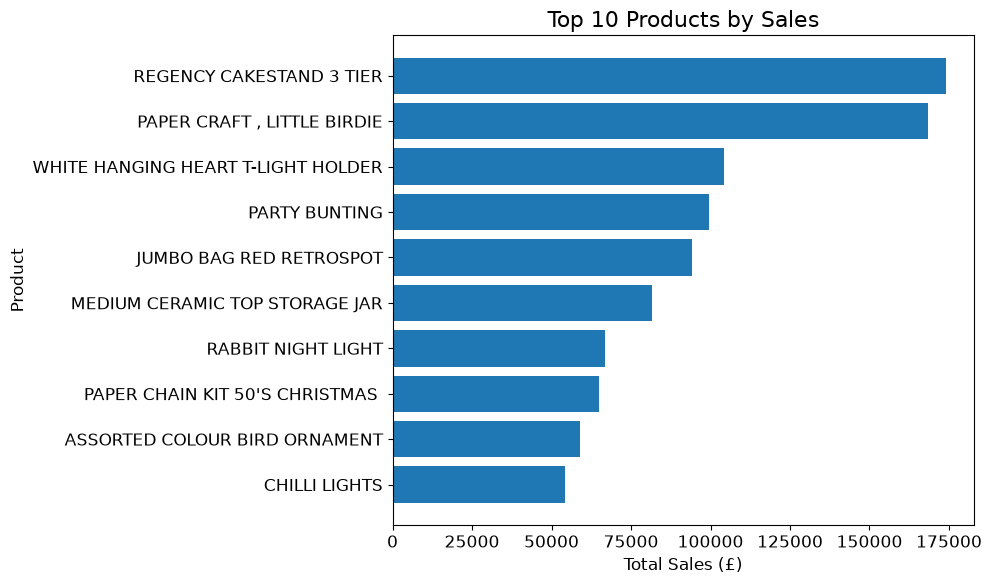

In [68]:
top_products = (
    product_sales
    .head(10)
    .sort_values("TotalSales")
)

plt.figure(figsize=(10,6))

plt.barh(
    top_products.index.get_level_values("Description"),
    top_products["TotalSales"]
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Total Sales (£)")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

#### Observation

The chart makes it easier to compare the revenue generated by the highest-performing products.

Although several products contribute strongly to sales, the difference between them is clearly visible.